In [1]:
import sys
sys.path.append("../")

from methods.Steepest_descent import (gradient_descent)
from methods.Error import (save_iterations, history, calculate_precision, plot_methods_error, ten_iterations)
from methods.Newton_method import (newton_method)
from methods.Conjugate_method import (conjugate_gradient)
import numpy as np
import os
import matplotlib.pyplot as plt

-----------------------------
Method:  Gradient_descent
Minimum point:  [3.21829795 3.21829795]
Function value at minimum:  28.96468153816889
Number of iterations:  129
-----------------------------


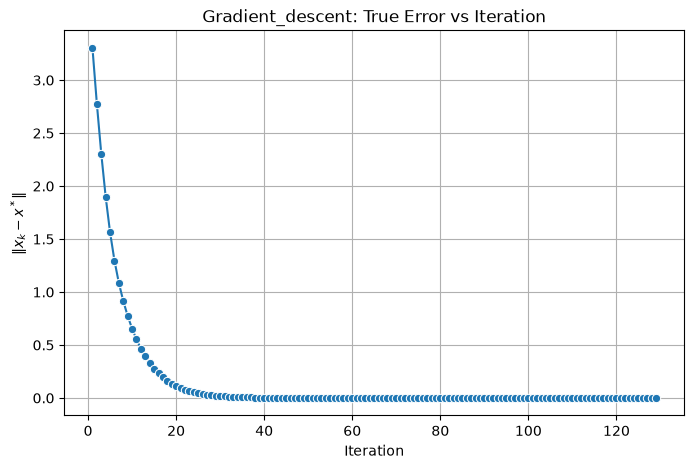

-----------------------------
Method:  Newton Method
Minimum point:  [3.21829795 3.21829795]
Function value at minimum:  28.96468153816889
Number of iterations:  9
-----------------------------


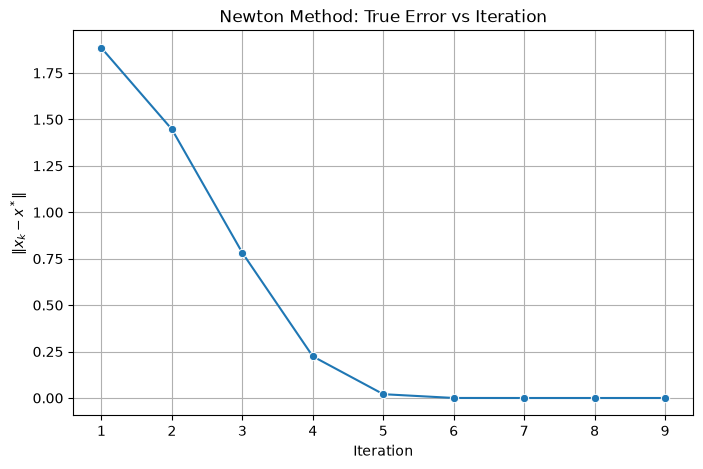

-----------------------------
Method:  Conjugate Gradient Method
Minimum point:  [-1501376.68723682 -1486341.05928342]
Function value at minimum:  -8963153.23956072
Number of iterations:  1000
-----------------------------


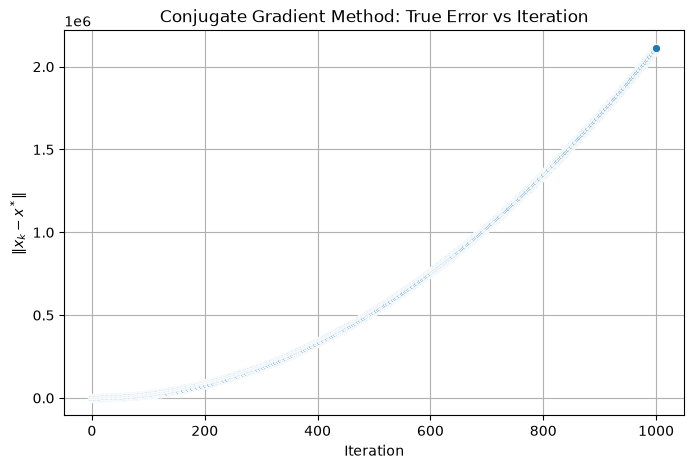

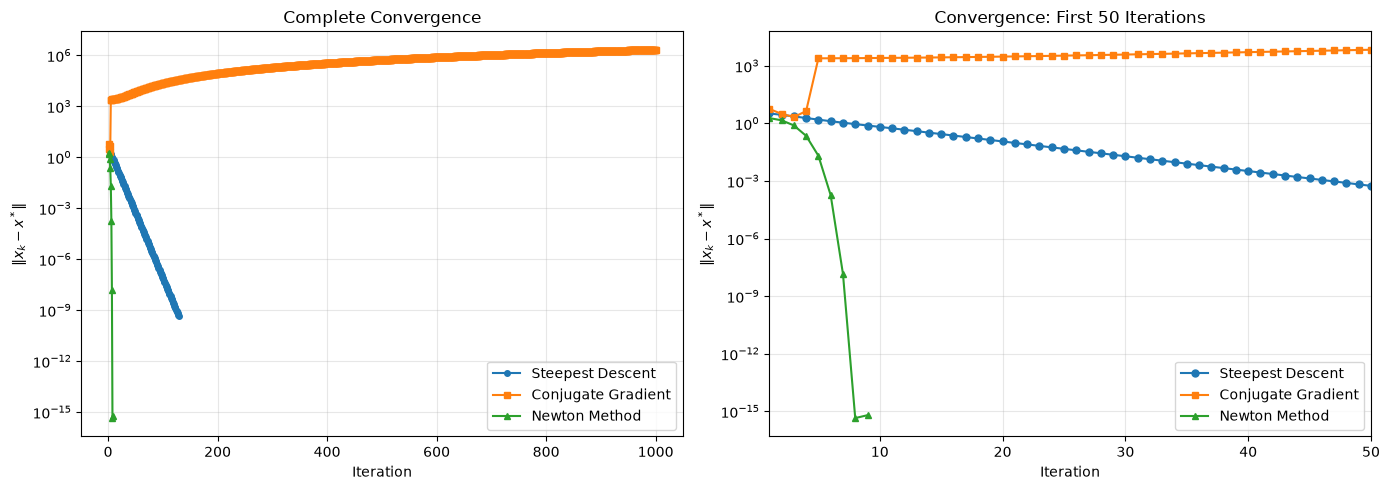

Plot saved: results\plots\methods_comparison_error.png
               Method  Iterations   Final Error  Correct Decimals
0    Steepest Descent         129  4.449149e-10                 9
1  Conjugate Gradient        1000  2.112667e+06                 0
2       Newton Method           9  6.280370e-16                14

Database saved: results\methods_precision.csv
                Method  iteration           x1         x2         f(x)  \
0     Steepest Descent          1     6.296713   4.416337    35.735184   
1     Steepest Descent          2     5.872585   4.034669    33.942252   
2     Steepest Descent          3     5.474227   3.693478    32.448974   
3     Steepest Descent          4     5.108140   3.403453    31.286759   
4     Steepest Descent          5     4.780915   3.174712    30.455352   
5     Steepest Descent          6     4.497700   3.013243    29.911453   
6     Steepest Descent          7     4.260314   2.916983    29.578715   
7     Steepest Descent          8     4.06

In [2]:
import numpy as np

def f(x, y):
    d = 3
    return 3*x + 100/(x*y) + d*y


def df_dx(x, y):
    d = 3
    return 3 - 100/(x**2 * y)


def df_dy(x, y):
    d = 3
    return -100/(x * y**2) + d

def gradient(x, y):
    return np.array([
        df_dx(x, y),
        df_dy(x, y)
    ])

def hessian(x, y):
    return np.array([
        [
            200/(x**3 * y),
            100/(x**2 * y**2)
        ],
        [
            100/(x**2 * y**2),
            200/(x * y**3)
        ]
    ])


def printing(method, minimum, f_min, iterations):
    print("-----------------------------")
    print("Method: ", method)
    print("Minimum point: ", minimum)
    print("Function value at minimum: ", f_min)
    print("Number of iterations: ", iterations)
    print("-----------------------------")



d = 3
x0 = np.array([1.0, 3.0])
tol = 1e-10
max_iter = 1000


# ============================================================
# Exact solution
# ============================================================
x_exact = np.array([
    (100/3)**(1/3),
    (100/3)**(1/3)
])


# ============================================================
# Step size for Steepest Descent
# ============================================================

alpha = 0.174616899 


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Steepest Descent
    # --------------------------------------------------------

    minimum, f_min, iterations, history_data = gradient_descent(
        x0,
        f,
        gradient,
        tol,
        max_iter,
        alpha,
        history
    )

    printing(
        'Gradient_descent',
        minimum,
        f_min,
        iterations
    )

    df_gradient = save_iterations(
        history_data,
        "Gradient_descent",
        x_exact
    )


    # --------------------------------------------------------
    # Newton Method
    # --------------------------------------------------------

    minimum, f_min, iterations, history_data = newton_method(
        x0,
        f,
        gradient,
        hessian,
        tol,
        max_iter,
        alpha,
        history
    )

    printing(
        'Newton Method',
        minimum,
        f_min,
        iterations
    )

    df_newton = save_iterations(
        history_data,
        "Newton Method",
        x_exact
    )


    # --------------------------------------------------------
    # Conjugate Gradient
    # --------------------------------------------------------

    minimum, f_min, iterations, history_data = conjugate_gradient(
        x0,
        f,
        gradient,
        tol,
        max_iter,
        history
    )

    printing(
        'Conjugate Gradient Method',
        minimum,
        f_min,
        iterations
    )

    df_conjugate = save_iterations(
        history_data,
        "Conjugate Gradient Method",
        x_exact
    )


    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    results_path = "results"

    plot_methods_error(results_path)

    calculate_precision(results_path)

    ten_iterations(results_path)